In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import math

In [30]:
Z_A = 10       # profundidad vehículo A en metros
Z_B = 10       # profundidad vehículo B en metros (igual que A para triángulo simétrico)
u_A = 400      # posición horizontal bbox A en píxeles (izquierda de cx)
u_B = 1480     # posición horizontal bbox B en píxeles (derecha de cx)
cx  = 936.30   # punto principal horizontal
fx  = 1483.37  # distancia focal eje X

In [31]:
alpha = np.arctan((u_A - cx) / fx)
beta  = np.arctan((u_B - cx) / fx)
r_A   = Z_A / np.cos(alpha)
r_B   = Z_B / np.cos(beta)
theta = abs(alpha - beta)
d_AB  = np.sqrt(r_A**2 + r_B**2 - 2*r_A*r_B*np.cos(theta))
 
# Coordenadas geométricas
# C en origen, A y B calculados desde los ángulos
C = np.array([0, 0])
A = np.array([r_A * np.sin(alpha), r_A * np.cos(alpha)])
B = np.array([r_B * np.sin(beta),  r_B * np.cos(beta)])
 
print(f"α = {np.degrees(alpha):.2f}°")
print(f"β = {np.degrees(beta):.2f}°")
print(f"r_A = {r_A:.2f} m")
print(f"r_B = {r_B:.2f} m")
print(f"θ = {np.degrees(theta):.2f}°")
print(f"d_AB = {d_AB:.2f} m")

α = -19.88°
β = 20.13°
r_A = 10.63 m
r_B = 10.65 m
θ = 40.01°
d_AB = 7.28 m


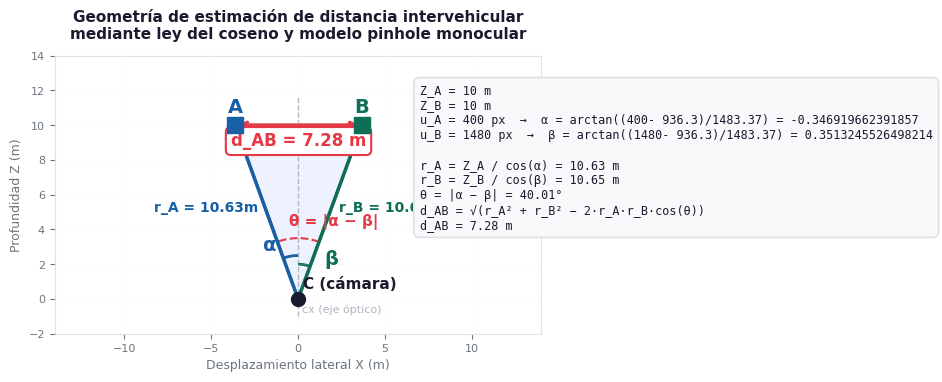

In [46]:
fig, ax = plt.subplots(figsize=(9, 8), facecolor='white')
ax.set_facecolor('white')
ax.set_aspect('equal')

# Triángulo relleno
triangulo = plt.Polygon([C, A, B],
                         fill=True,
                         facecolor='#EEF2FF',
                         edgecolor='#1A1A2E',
                         linewidth=2)
ax.add_patch(triangulo)

# Eje óptico (línea punteada)
ax.plot([0, 0], [-1, max(r_A, r_B) + 1],
        color='#ADB5BD', linewidth=1,
        linestyle='--', zorder=1)

# Lado r_A (azul)
ax.annotate('', xy=A, xytext=C,
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=2.5))
mid_rA = (C + A) / 2
ax.text(mid_rA[0] - 0.5, mid_rA[1],
        f'r_A = {r_A:.2f}m',
        fontsize=10, color='#185FA5',
        fontweight='bold', ha='right')

# Lado r_B (verde)
ax.annotate('', xy=B, xytext=C,
            arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=2.5))
mid_rB = (C + B) / 2
ax.text(mid_rB[0] + 0.5, mid_rB[1],
        f'r_B = {r_B:.2f}m',
        fontsize=10, color='#0F6E56',
        fontweight='bold', ha='left')

# Lado d_AB (rojo, base del triángulo)
ax.annotate('', xy=B, xytext=A,
            arrowprops=dict(arrowstyle='<->', color='#E63946', lw=2.5))
mid_dAB = (A + B) / 2
ax.text(mid_dAB[0], mid_dAB[1] - 1.2,
        f'd_AB = {d_AB:.2f} m',
        fontsize=12, color='#E63946',
        fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor='#E63946',
                  linewidth=1.5))

# Arco α (ángulo de A respecto al eje óptico)
arc_alpha = patches.Arc(C, 5, 5,
                         angle=90,
                         theta1=0,
                         theta2=np.degrees(abs(alpha)),
                         color='#185FA5', linewidth=2)
ax.add_patch(arc_alpha)
ax.text(-2.0, 2.8, 'α',
        fontsize=14, color='#185FA5', fontweight='bold')

# Arco β (ángulo de B respecto al eje óptico)
arc_beta = patches.Arc(C, 4, 4,
                        angle=90,
                        theta1=-np.degrees(beta),
                        theta2=0,
                        color='#0F6E56', linewidth=2)
ax.add_patch(arc_beta)
ax.text(1.5, 2.0, 'β',
        fontsize=14, color='#0F6E56', fontweight='bold')

# Arco θ (ángulo total entre r_A y r_B)
arc_theta = patches.Arc(C, 7, 7,
                         angle=90,
                         theta1=-np.degrees(beta),
                         theta2=np.degrees(abs(alpha)),
                         color='#E63946',
                         linewidth=1.5,
                         linestyle='--')
ax.add_patch(arc_theta)
ax.text(-0.5, 4.2, 'θ = |α − β|',
        fontsize=11, color='#E63946', fontweight='bold')

# Puntos
ax.plot(*C, 'o', color='#1A1A2E', markersize=10, zorder=5)
ax.plot(*A, 's', color='#185FA5', markersize=12, zorder=5)
ax.plot(*B, 's', color='#0F6E56', markersize=12, zorder=5)

# Etiquetas puntos
ax.text(0.3, 0.6, 'C (cámara)',
        fontsize=11, fontweight='bold', color='#1A1A2E')
ax.text(A[0], A[1] + 0.7, 'A',
        fontsize=14, fontweight='bold',
        color='#185FA5', ha='center')
ax.text(B[0], B[1] + 0.7, 'B',
        fontsize=14, fontweight='bold',
        color='#0F6E56', ha='center')

# Etiqueta eje óptico / cx
ax.text(0.2, -0.8, 'cx (eje óptico)',
        fontsize=8, color='#ADB5BD', ha='left')

# Cuadro de fórmulas
formula_text = (
    f"Z_A = {Z_A} m\n"
    f"Z_B = {Z_B} m\n"
    f"u_A = {u_A} px  →  α = arctan(({u_A}- {cx})/{fx}) = {math.atan((u_A-cx)/fx)}\n"
    f"u_B = {u_B} px  →  β = arctan(({u_B}- {cx})/{fx}) = {math.atan((u_B-cx)/fx)}\n\n"
    f"r_A = Z_A / cos(α) = {r_A:.2f} m\n"
    f"r_B = Z_B / cos(β) = {r_B:.2f} m\n"
    f"θ = |α − β| = {np.degrees(theta):.2f}°\n"
    f"d_AB = √(r_A² + r_B² − 2·r_A·r_B·cos(θ))\n"
    f"d_AB = {d_AB:.2f} m"
)
ax.text(0.75, 0.90, formula_text,
        transform=ax.transAxes,
        fontsize=8.5, color='#1A1A2E',
        va='top', ha='left',
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='#F8F9FA',
                  edgecolor='#DEE2E6',
                  linewidth=1.2))

ax.set_title(
    'Geometría de estimación de distancia intervehicular\n'
    'mediante ley del coseno y modelo pinhole monocular',
    fontsize=11, fontweight='bold',
    color='#1A1A2E', pad=12
)
ax.set_xlabel('Desplazamiento lateral X (m)', fontsize=9, color='#6C757D')
ax.set_ylabel('Profundidad Z (m)', fontsize=9, color='#6C757D')
ax.tick_params(colors='#6C757D', labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#DEE2E6')

ax.set_xlim(-14, 14)
ax.set_ylim(-2, 14)
ax.grid(True, alpha=0.15, color='#DEE2E6', linewidth=0.5)

plt.tight_layout()
plt.show()